In [23]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, util, color, transform, filters, feature, draw, registration

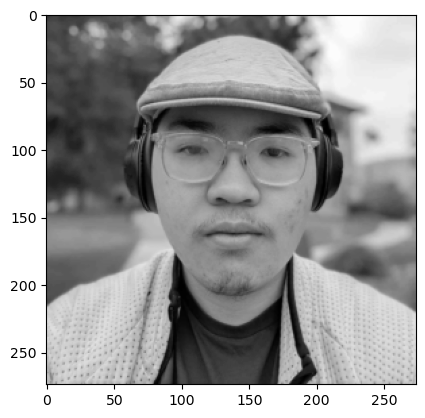

In [24]:
# load input image
img = util.img_as_float32( color.rgb2gray( io.imread('./assignment1_photo.jpg') ) )
img = transform.rescale(img, 1/5)
plt.imshow(img, cmap='gray')
plt.show()

EXERSICE 1

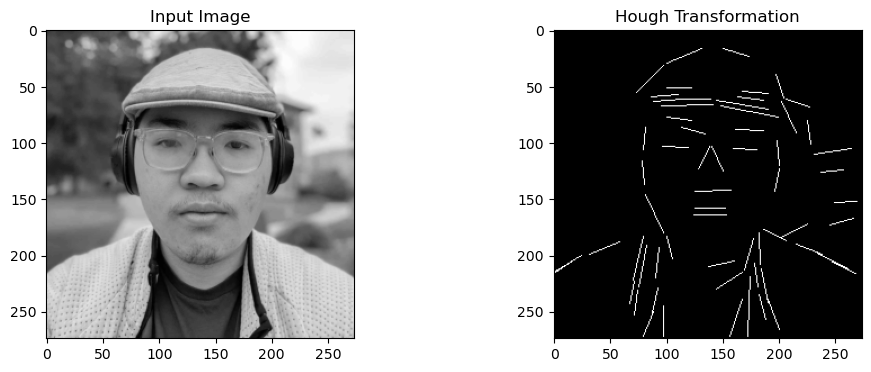

In [25]:
# Hough Transform, ref from the turtorial codes 
edges = feature.canny(img, sigma=2, low_threshold=0.1, high_threshold=0.2)
lines = transform.probabilistic_hough_line(edges,threshold=2, line_length=20, line_gap=2)

# line image
img_lines = np.zeros_like(img)
for line in lines:
    p0, p1 = line
    rr, cc = draw.line(p0[1], p0[0], p1[1], p1[0])
    img_lines[rr,cc] = 1
    

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4) )
ax[0].imshow(img)
ax[0].set_title("Input Image")
ax[1].imshow(img_lines)
ax[1].set_title("Hough Transformation")
plt.show()

EXERCISE 2

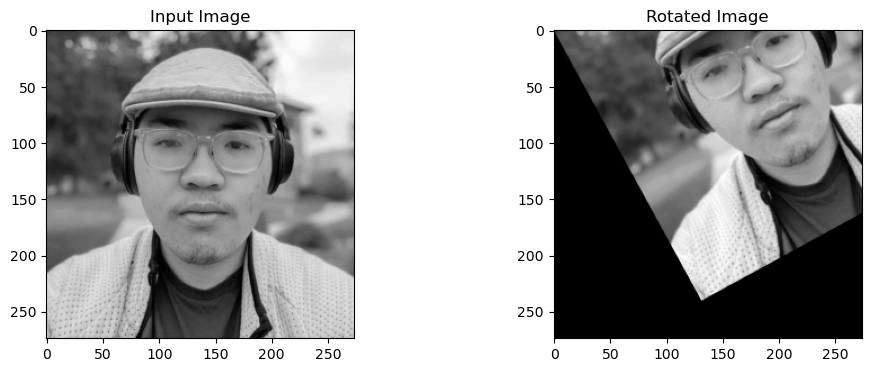

In [30]:
# rotate
tform = transform.AffineTransform(scale=(1,1), rotation=0.5) #, translation=(75,-50))
img2 = transform.warp(img, tform)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4) )
ax[0].imshow(img)
ax[0].set_title("Input Image")
ax[1].imshow(img2)
ax[1].set_title("Rotated Image")
plt.show()

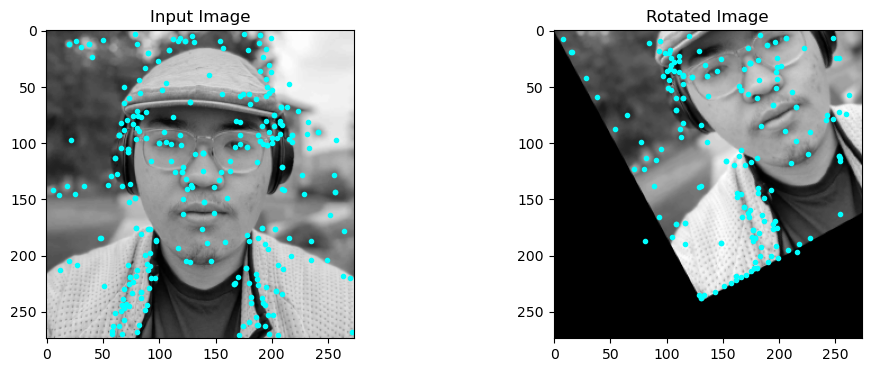

In [31]:
# SIFT
descriptor_extractor = feature.SIFT()

descriptor_extractor.detect_and_extract(img)
input_keypoints = descriptor_extractor.keypoints
input_descriptors = descriptor_extractor.descriptors

descriptor_extractor.detect_and_extract(img2)
rotate_keypoints = descriptor_extractor.keypoints
rotate_descriptors = descriptor_extractor.descriptors

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4) )
ax[0].imshow(img)
ax[0].plot(input_keypoints[:,1], input_keypoints[:,0], color='cyan', marker='o', linestyle='none', markersize=3)
ax[0].set_title("Input Image")
ax[1].imshow(img2)
ax[1].plot(rotate_keypoints[:,1], rotate_keypoints[:,0], color='cyan', marker='o', linestyle='none', markersize=3)
ax[1].set_title("Rotated Image")
plt.show()

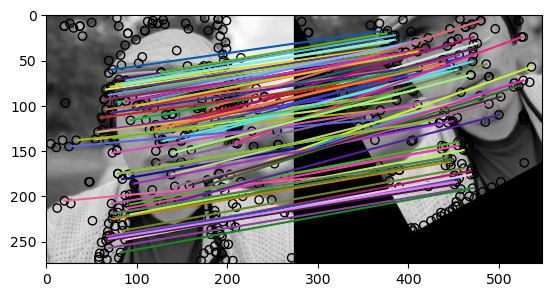

In [32]:
# Matching
matches = feature.match_descriptors(input_descriptors, rotate_descriptors, max_ratio=0.7, cross_check=True)


fig, ax = plt.subplots()

feature.plot_matches(
    ax,
    img,
    img2,
    keypoints1=input_keypoints,
    keypoints2=rotate_keypoints,
    matches=matches)

EXERCISE 3

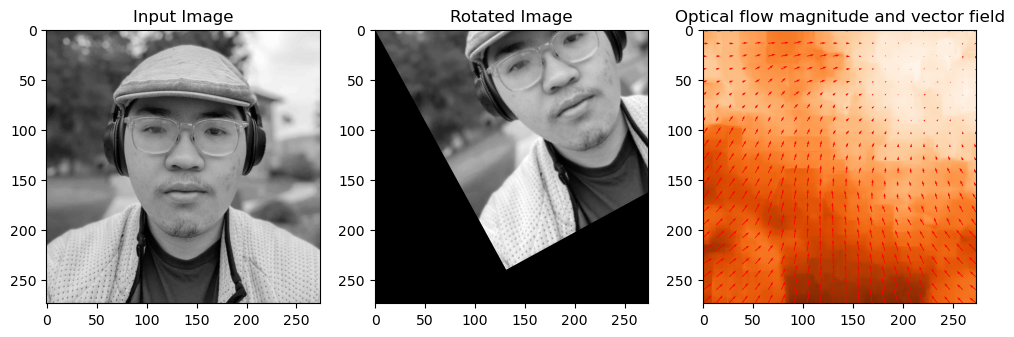

In [33]:
# Lucas-Kanade optical flow, ref using the turtorial codes
v,u = registration.optical_flow_ilk(img, img2)

# optical flow norm
norm = np.sqrt(u**2 + v**2)

# Quiver plot arrows
nvec = 20  # Number of vectors to be displayed along each image dimension
nl, nc = img.shape
step = max(nl // nvec, nc // nvec)
y, x = np.mgrid[0:nl:step, 0:nc:step]
u_ = u[0::step, 0::step]
v_ = v[0::step, 0::step]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4) )
ax[0].imshow(img)
ax[0].set_title("Input Image")
ax[1].imshow(img2)
ax[1].set_title("Rotated Image")
ax[2].imshow(norm, cmap='Oranges')
ax[2].quiver(x, y, u_, v_, color='r', units='dots', angles='xy', scale_units='xy', lw=3)
ax[2].set_title("Optical flow magnitude and vector field")
plt.show()